In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recreate the dataset (15 samples)
np.random.seed(42)
x1 = np.random.rand(15) * 10
x2 = np.random.rand(15) * 5
y_raw = 2 + 3*x1 + 5*x2 + np.random.randn(15) * 2

df = pd.DataFrame({'Feature 1': x1, 'Feature 2': x2, 'Predictor (y)': y_raw})

df

,Feature 1,Feature 2,Predictor (y)
0,3.745401,0.917023,15.519329
1,9.507143,1.521211,38.878881
2,7.319939,2.623782,35.877452
3,5.986585,2.159725,30.174992
4,1.560186,1.456146,12.757874
5,1.559945,3.059264,25.680714
6,0.580836,0.697469,7.202860
7,8.661761,1.460723,33.173479
8,6.011150,1.831809,30.837586
9,7.080726,2.280350,32.202240


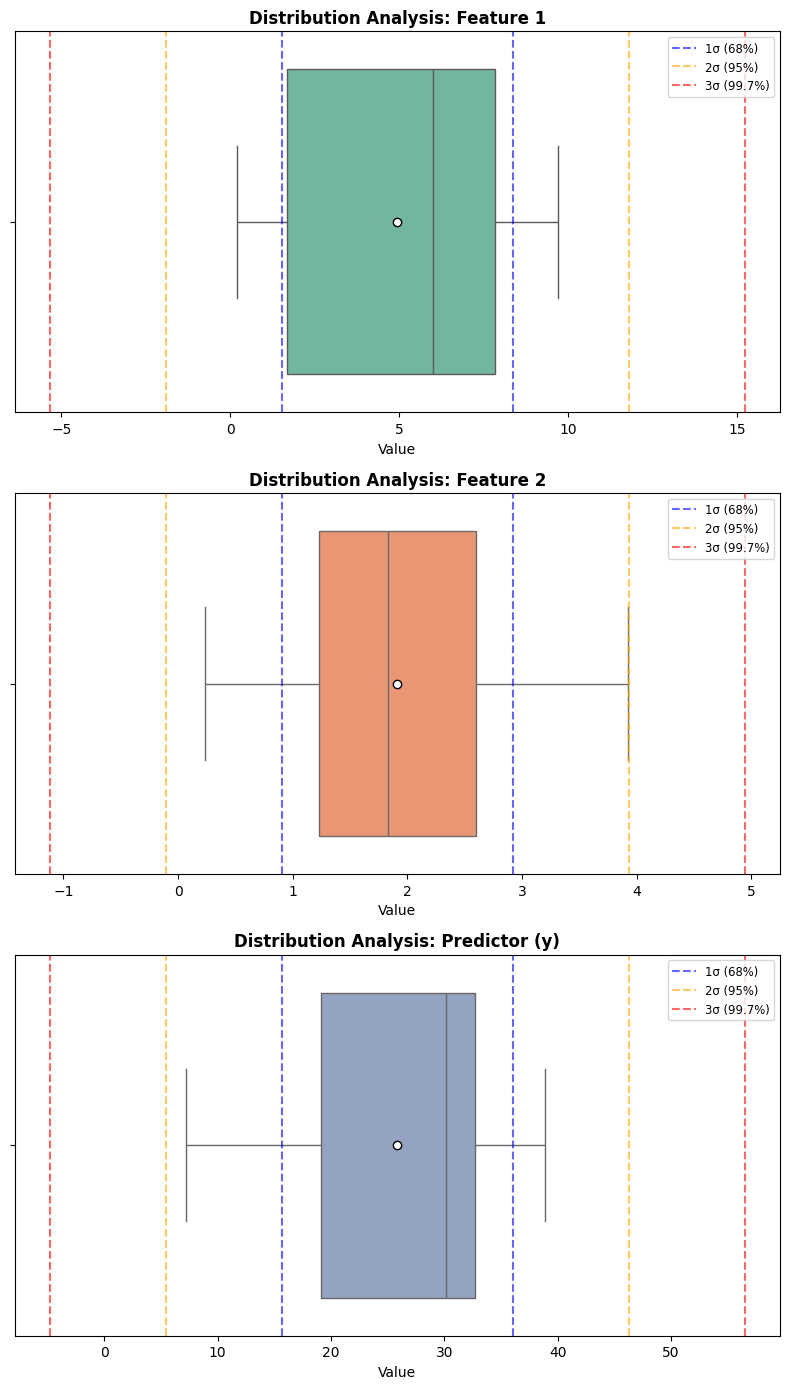

--- Descriptive Statistics ---
                     Feature 1  Feature 2  Predictor (y)
mean                  4.945646   1.913150      25.865323
std                   3.429607   1.010823      10.231220
25%                   1.689218   1.227257      19.091995
median (IQR Middle)   5.986585   1.831809      30.174992
75%                   7.822183   2.597477      32.687859


In [2]:
# 2. Setup Plotting (3 Vertical Subplots)
fig, axes = plt.subplots(3, 1, figsize=(8, 14))
cols = ['Feature 1', 'Feature 2', 'Predictor (y)']
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

for i, col in enumerate(cols):
    data = df[col]
    mu, sigma = data.mean(), data.std()
    
    # Create Boxplot with custom outlier (flier) props
    sns.boxplot(x=data, ax=axes[i], color=colors[i], 
                flierprops={"marker": "^", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": 10},
                showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
    
    # Standard Deviation Lines (Empirical Rule)
    axes[i].axvline(mu + sigma, color='blue', linestyle='--', alpha=0.6, label='1σ (68%)')
    axes[i].axvline(mu - sigma, color='blue', linestyle='--', alpha=0.6)
    
    axes[i].axvline(mu + 2*sigma, color='orange', linestyle='--', alpha=0.6, label='2σ (95%)')
    axes[i].axvline(mu - 2*sigma, color='orange', linestyle='--', alpha=0.6)
    
    axes[i].axvline(mu + 3*sigma, color='red', linestyle='--', alpha=0.6, label='3σ (99.7%)')
    axes[i].axvline(mu - 3*sigma, color='red', linestyle='--', alpha=0.6)
    
    axes[i].set_title(f'Distribution Analysis: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# 3. Print Descriptive Statistics as a DataFrame
summary_df = df.describe().loc[['mean', 'std', '25%', '50%', '75%']]
summary_df = summary_df.rename(index={'50%': 'median (IQR Middle)'})
print("--- Descriptive Statistics ---")
print(summary_df)

In [3]:
# 4. Print Summary Statistics (Numeric EDA)
print("--- Descriptive Statistics ---")
df.describe().loc[['mean', '50%', 'std', 'min', '25%', '75%', 'max']]

--- Descriptive Statistics ---


,Feature 1,Feature 2,Predictor (y)
mean,4.945646,1.913150,25.865323
50%,5.986585,1.831809,30.174992
std,3.429607,1.010823,10.231220
min,0.205845,0.232252,7.202860
25%,1.689218,1.227257,19.091995
75%,7.822183,2.597477,32.687859
max,9.699099,3.925880,38.878881


In [4]:
# CREATE X_RAW (15x2 Matrix)
X_raw = np.column_stack((x1, x2))
# Add bias term (column of 1s) to X
X = np.c_[np.ones((15, 1)), X_raw]
# ensure that our target variable is a 2D column vector (15×1) rather than a 1D row array
y = y_raw.reshape(-1, 1)

print(X)

[[1.         3.74540119 0.91702255]
 [1.         9.50714306 1.52121121]
 [1.         7.31993942 2.62378216]
 [1.         5.98658484 2.15972509]
 [1.         1.5601864  1.4561457 ]
 [1.         1.5599452  3.05926447]
 [1.         0.58083612 0.6974693 ]
 [1.         8.66176146 1.46072324]
 [1.         6.01115012 1.83180922]
 [1.         7.08072578 2.28034992]
 [1.         0.20584494 3.92587981]
 [1.         9.69909852 0.99836891]
 [1.         8.32442641 2.57117219]
 [1.         2.12339111 2.96207284]
 [1.         1.81824967 0.23225206]]


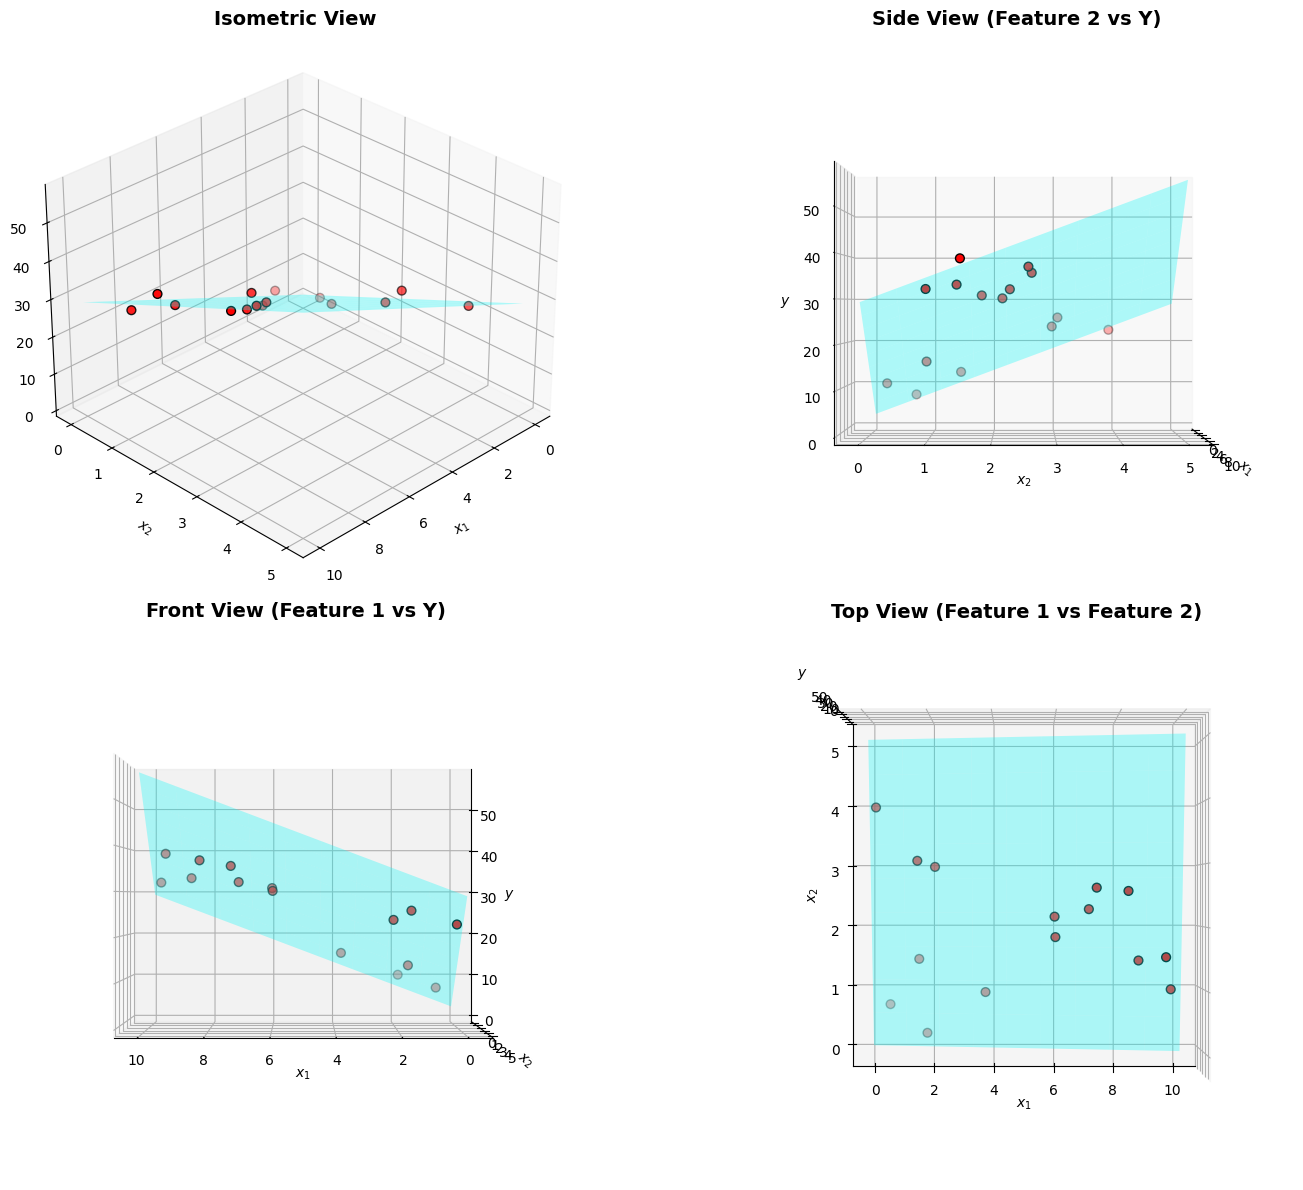

Final OLS Model: y = 2.37 + 2.69*x1 + 5.32*x2


In [5]:
from mpl_toolkits.mplot3d import Axes3D

# 2. OLS Solution
theta_ols = np.linalg.inv(X.T @ X) @ X.T @ y
w0, w1, w2 = theta_ols.flatten()

# 3. Setup Meshgrid for the Plane
x_range = np.linspace(0, 10, 10)
y_range = np.linspace(0, 5, 10)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_grid = w0 + w1 * X_grid + w2 * Y_grid

# 4. Create Subplots for Multiple Views
fig = plt.figure(figsize=(16, 12))

# Define views: (elevation, azimuth, title)
views = [
    (30, 45, 'Isometric View'),
    (0, 0, 'Side View (Feature 2 vs Y)'),
    (0, 90, 'Front View (Feature 1 vs Y)'),
    (90, -90, 'Top View (Feature 1 vs Feature 2)')
]

for i, (elev, azim, title) in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # Plot Data Points
    ax.scatter(x1, x2, y_raw, color='red', s=40, label='Data Points', edgecolors='black')
    
    # Plot Fitted Plane
    ax.plot_surface(X_grid, Y_grid, Z_grid, alpha=0.3, color='cyan', edgecolor='none')
    
    # Formatting
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$y$')

plt.tight_layout()
plt.show()

print(f"Final OLS Model: y = {w0:.2f} + {w1:.2f}*x1 + {w2:.2f}*x2")

--- Gradient Descent Iteration Log ---
Pass 00: Weights = [ 0.30557811  0.69105457 -0.02320176]
Pass 10: Weights = [0.88381171 3.57246841 1.29833687]
Pass 20: Weights = [1.05771217 3.78988771 1.83097958]
Pass 30: Weights = [1.17296044 3.70901783 2.23021113]
Pass 40: Weights = [1.27118757 3.60485691 2.57710931]
Pass 50: Weights = [1.35836398 3.50827707 2.88514881]
Pass 60: Weights = [1.43617303 3.42176368 3.15946977]
Pass 70: Weights = [1.50568987 3.34460751 3.40385029]
Pass 80: Weights = [1.5678229  3.27583493 3.6215633 ]
Pass 90: Weights = [1.62337584 3.21453839 3.81551437]
Pass 99: Weights = [1.66834052 3.16508941 3.97189876]


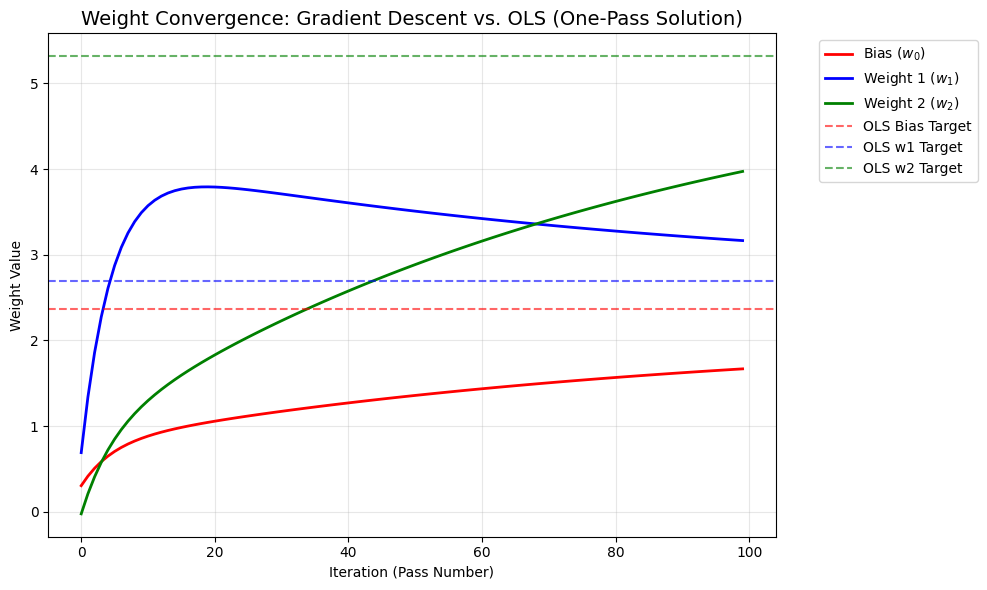

In [6]:
# 2. Ordinary Least Squares (OLS) - The "One Pass" solution
theta_ols = np.linalg.inv(X.T @ X) @ X.T @ y

# 3. Gradient Descent
learning_rate = 0.0025
n_iterations = 100
theta = np.random.randn(3, 1) # Random start
history = []

print("--- Gradient Descent Iteration Log ---")
for i in range(n_iterations):
    # Gradient of MSE: (2/m) * X^T * (X*theta - y)
    gradients = 2/15 * X.T @ (X @ theta - y)
    theta = theta - learning_rate * gradients
    history.append(theta.flatten().copy())
    
    # Print specific passes
    if i % 10 == 0 or i == n_iterations - 1:
        print(f"Pass {i:02d}: Weights = {theta.flatten()}")

history = np.array(history)

# 4. Visualization of Weight Convergence
plt.figure(figsize=(10, 6))
plt.plot(history[:, 0], label='Bias ($w_0$)', color='red', linewidth=2)
plt.plot(history[:, 1], label='Weight 1 ($w_1$)', color='blue', linewidth=2)
plt.plot(history[:, 2], label='Weight 2 ($w_2$)', color='green', linewidth=2)

# Horizontal lines for OLS targets
plt.axhline(y=theta_ols[0], color='red', linestyle='--', alpha=0.6, label='OLS Bias Target')
plt.axhline(y=theta_ols[1], color='blue', linestyle='--', alpha=0.6, label='OLS w1 Target')
plt.axhline(y=theta_ols[2], color='green', linestyle='--', alpha=0.6, label='OLS w2 Target')

plt.title("Weight Convergence: Gradient Descent vs. OLS (One-Pass Solution)", fontsize=14)
plt.xlabel("Iteration (Pass Number)")
plt.ylabel("Weight Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

--- Gradient Descent Trace (First 5 Passes) ---
Pass 0: w1=3.0961, w2=0.3812, Loss=132.1736
Pass 1: w1=3.9721, w2=0.8669, Loss=65.8929
Pass 2: w1=4.1192, w2=1.1412, Loss=57.4122
Pass 3: w1=4.1030, w2=1.3601, Loss=52.3672
Pass 4: w1=4.0520, w2=1.5591, Loss=47.9122


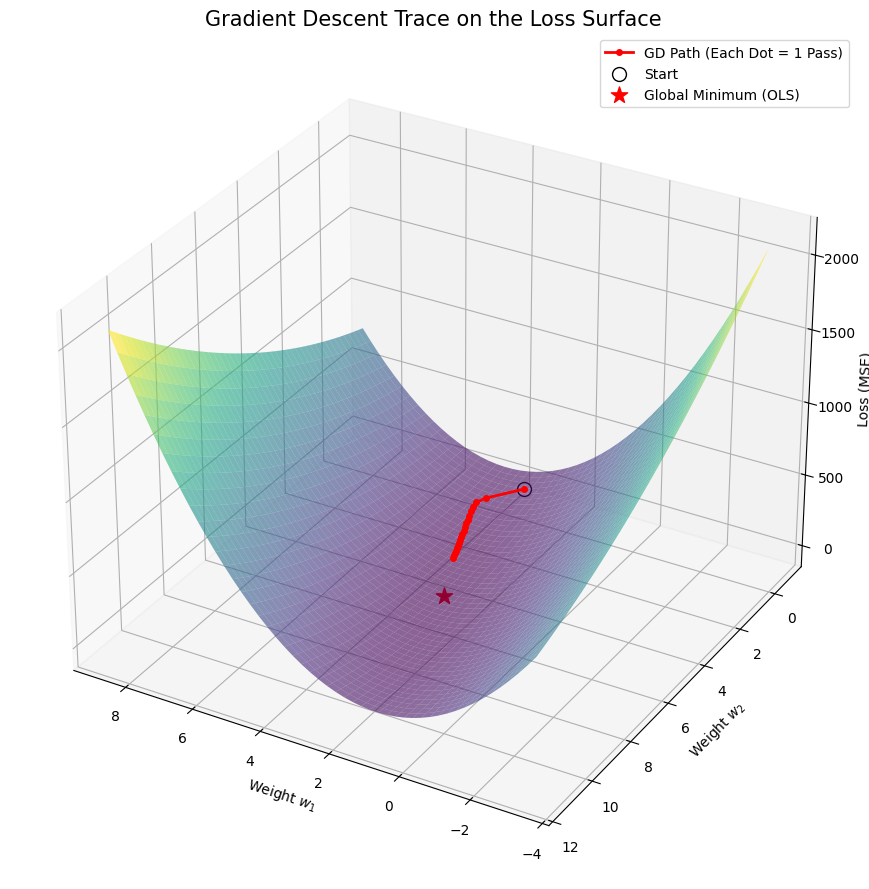

In [7]:
# 3. Gradient Descent Trace

# setting these values only for visual purposes
# it will overshoot
# use the values used in the above code block
learning_rate = 0.01
n_iterations = 20
theta = np.array([-1.0, -1.0, -1.0]).reshape(3, 1) # Start far away for a good trace
history = []

for i in range(n_iterations):
    gradients = 2/15 * X.T @ (X @ theta - y)
    theta = theta - learning_rate * gradients
    # Calculate MSE at this step
    mse = np.mean((X @ theta - y)**2)
    history.append([theta[1, 0], theta[2, 0], mse])

history = np.array(history)

# 4. Generate Loss Surface (varying w1, w2; fixing w0 at optimal)
w1_range = np.linspace(w1 - 6, w1 + 6, 50)
w2_range = np.linspace(w2 - 6, w2 + 6, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_mse = np.zeros(W1.shape)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        y_pred = w0 + W1[i, j] * X_raw[:, 0] + W2[i, j] * X_raw[:, 1]
        Z_mse[i, j] = np.mean((y_pred - y.flatten())**2)

# 5. Plotting the Trace
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Surface
surf = ax.plot_surface(W1, W2, Z_mse, cmap='viridis', alpha=0.6, edgecolor='none')

# Trace (The path taken by GD)
ax.plot(history[:, 0], history[:, 1], history[:, 2], color='red', marker='o', 
        markersize=4, linewidth=2, label='GD Path (Each Dot = 1 Pass)', zorder=10)

# Start and End points
ax.scatter(history[0, 0], history[0, 1], history[0, 2], color='white', s=100, edgecolors='black', label='Start')
ax.scatter(w1, w2, np.mean((X @ theta_ols - y)**2), color='red', s=150, marker='*', label='Global Minimum (OLS)')

ax.set_xlabel('Weight $w_1$')
ax.set_ylabel('Weight $w_2$')
ax.set_zlabel('Loss (MSE)')
ax.set_title('Gradient Descent Trace on the Loss Surface', fontsize=15)
ax.legend()
ax.view_init(elev=30, azim=120) # Better angle to see the descent

plt.tight_layout()

# Print first few steps of the trace
print("--- Gradient Descent Trace (First 5 Passes) ---")
for i in range(5):
    print(f"Pass {i}: w1={history[i,0]:.4f}, w2={history[i,1]:.4f}, Loss={history[i,2]:.4f}")